In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_raw = pd.read_csv("../student_data_categorized.csv")

In [4]:
df_raw.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   str    
 1   Application mode                4424 non-null   int64  
 2   Application order               4424 non-null   int64  
 3   Course                          4424 non-null   str    
 4   Daytime/evening attendance      4424 non-null   str    
 5   Previous qualification          4424 non-null   str    
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nacionality                     4424 non-null   str    
 8   Mother's qualification          4424 non-null   str    
 9   Father's qualification          4424 non-null   str    
 10  Mother's occupation             4424 non-null   str    
 11  Father's occupation             4424 non-null   str    
 12  Admission grade                 4424 non-null

The dataset contains 4,424 student records and 37 variables. Each row represents an individual student, while each column represents a demographic, educational, or academic characteristic. The dataset contains no missing values, as all variables have 4,424 non-null observations. Variables include student demographics, parental background, admission information, academic performance, and final enrollment outcomes.

In [6]:
for column in df_raw.columns:
    print(column)

Marital status
Application mode
Application order
Course
Daytime/evening attendance
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
1st_sem_credited
1st_sem_enrolled
1st_sem_evaluations
1st_sem_approved
1st_sem_grade
1st_sem_without_eval
2nd_sem_credited
2nd_sem_enrolled
2nd_sem_evaluations
2nd_sem_approved
2nd_sem_grade
2nd_sem_without_eval
Unemployment rate
Inflation rate
GDP
Target


Main Question #3: What subgroup of students are the most likely to drop out?

Guiding Questions: 
1. Does the age of enrollment correlate with the likelihood of dropping out?
2. How does marital status and gender influence the dropout rate?
3. How do parental education levels affect the probability of dropping out?
4. Does the number of curriculum units a student fails to evaluate, serve as an early warning sign for dropping out? 

Guiding Question #1: - Does age at enrollment correlate with student dropout? 


In [7]:
df_raw.groupby("Target")["Age at enrollment"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,1421.0,26.068966,8.704024,18.0,19.0,23.0,30.0,70.0
Enrolled,794.0,22.369018,6.302672,17.0,19.0,20.0,23.0,54.0
Graduate,2209.0,21.783612,6.693218,17.0,18.0,19.0,21.0,62.0


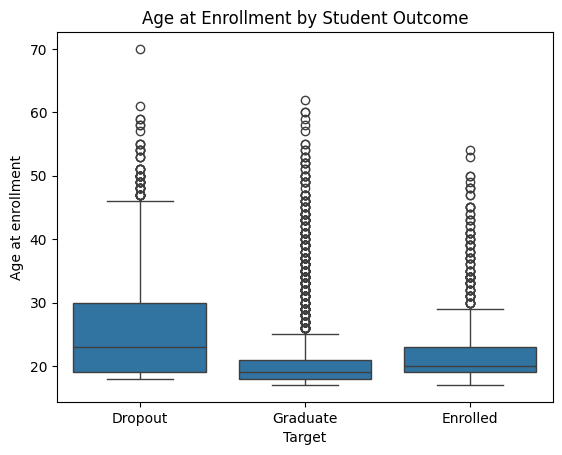

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Target",
    y="Age at enrollment",
    data = df_raw
)

plt.title("Age at Enrollment by Student Outcome")
plt.show()

It is evident from the boxplot that the students who have discontinued their studies usually joined them at an older age than those students who successfully completed their education. It is clear from the fact that the median age for dropouts is significantly higher than for graduates, which indicates that there could be a link between the age at which the students joined their studies and how well they fared. Furthermore, the variability for the dropout category was also higher as shown by the wider range for the box and whisker. However, there are older students in all categories.

Guiding Question 2 : How do gender and marital status influence student outcomes? 

In [9]:
df_raw["Gender Label"] = df_raw["Gender"].map({
    0: "Male",
    1: "Female",
})

In [10]:
pd.crosstab(
    df_raw["Gender Label"],
    df_raw["Target"],
    normalize="index"
) * 100

Target,Dropout,Enrolled,Graduate
Gender Label,,,
Female,45.051414,19.730077,35.218509
Male,25.104603,16.980474,57.914923


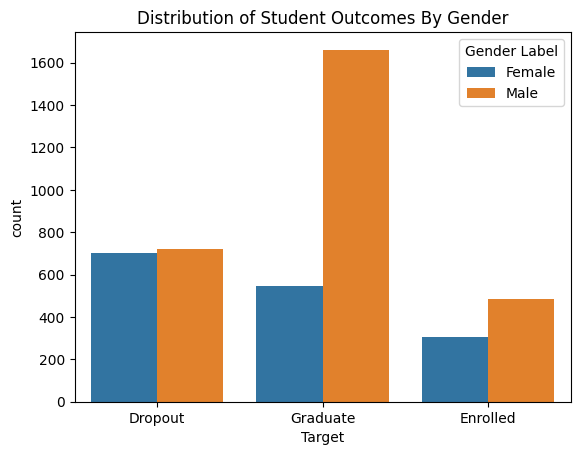

In [11]:
sns.countplot (
    x = 'Target',
    hue = 'Gender Label',
    data = df_raw
    
)

plt.title("Distribution of Student Outcomes By Gender")
plt.show()

The distribution of student outcomes appears to differ slightly between male and female students. While both genders are represented across all outcome categories, one gender appears to have a higher proportion of graduates and a lower proportion of dropouts. However, the differences are not as pronounced as those observed in the age analysis, suggesting that gender alone may not be a strong predictor of student dropout.

Guiding Question 2: 2. How does marital status and gender influence the dropout rate?

In [12]:
df_raw["Marital status"].value_counts()

Marital status
Single               3919
Married               379
Divorced               91
Facto Union            25
Legally Separated       6
Widower                 4
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df_raw["Marital status"],
    df_raw["Target"],
    normalize = "index"
) * 100

Target,Dropout,Enrolled,Graduate
Marital status,,,
Divorced,46.153846,17.582418,36.263736
Facto Union,44.000000,12.000000,44.000000
Legally Separated,66.666667,16.666667,16.666667
Married,47.229551,13.720317,39.050132
Single,30.211789,18.372034,51.416178
Widower,25.000000,50.000000,25.000000


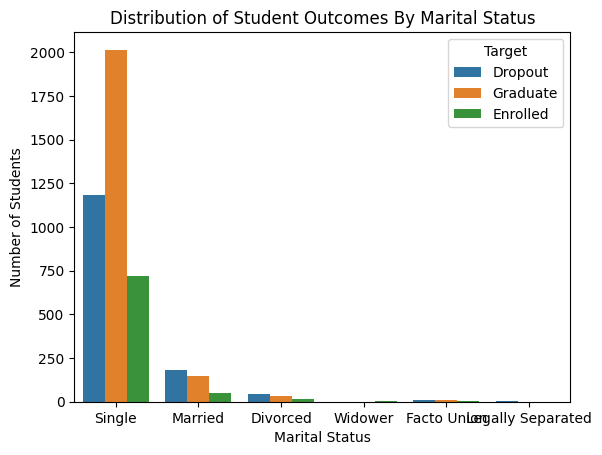

In [14]:
sns.countplot(
    x = "Marital status",
    hue = "Target",
    data = df_raw

)

plt.title("Distribution of Student Outcomes By Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Students")
plt.show()

The count plot shows that single students make up the overwhelming majority of the dataset, accounting for 3,919 of the 4,424 students. As a result, they have the largest number of graduates, dropouts, and enrolled students in absolute terms. However, because the marital status groups differ substantially in size, the count plot alone does not provide a fair comparison of dropout risk. The percentage table offers a more meaningful comparison by accounting for the size of each group. Based on the percentage analysis, married, divorced, and legally separated students experienced higher dropout rates than single students, suggesting that marital status may be associated with educational outcomes.

Guiding Question #3: 3. How do parental education levels affect the probability of dropping out?

In [35]:
# Display the frequency of each mother's education level
# to identify the most common qualification categories
df_raw["Mother's qualification"].value_counts()

Mother's qualification
Secondary Education - 12th Year of Schooling or Eq.         1069
Basic education 1st cycle (4th/5th year) or equiv.          1009
Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.     953
Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.       562
Higher Education - Degree                                    438
Unknown                                                      130
Higher Education - Bachelor's Degree                          83
Higher Education - Master's                                   49
Other - 11th Year of Schooling                                42
Higher Education - Doctorate                                  21
Higher education - degree (1st cycle)                          9
12th Year of Schooling - Not Completed                         8
Technological specialization course                            8
Specialized higher studies course                              6
Professional higher technical course                           4
Fr

In [48]:
# Display the frequency of each mother's education level
# to identify the most common qualification categories

df_raw["Mother's qualification"].value_counts()
top_mothers = df_raw["Mother's qualification"].value_counts().head(10).index

mother_df = df_raw[
    df_raw["Mother's qualification"].isin(top_mothers)
]

In [49]:
# Calculate the percentage of students who dropped out,
# remained enrolled, or graduated within each mother's
# education level category
(
    pd.crosstab(
        mother_df["Mother's qualification"],
        mother_df["Target"],
        normalize="index"
    ) * 100
).round(2)

Target,Dropout,Enrolled,Graduate
Mother's qualification,,,
Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.,24.91,16.19,58.90
Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.,28.44,18.47,53.10
Basic education 1st cycle (4th/5th year) or equiv.,37.96,16.75,45.29
Higher Education - Bachelor's Degree,24.10,27.71,48.19
Higher Education - Degree,31.74,23.06,45.21
Higher Education - Doctorate,38.10,23.81,38.10
Higher Education - Master's,16.33,30.61,53.06
Other - 11th Year of Schooling,52.38,7.14,40.48
Secondary Education - 12th Year of Schooling or Eq.,28.06,19.08,52.85


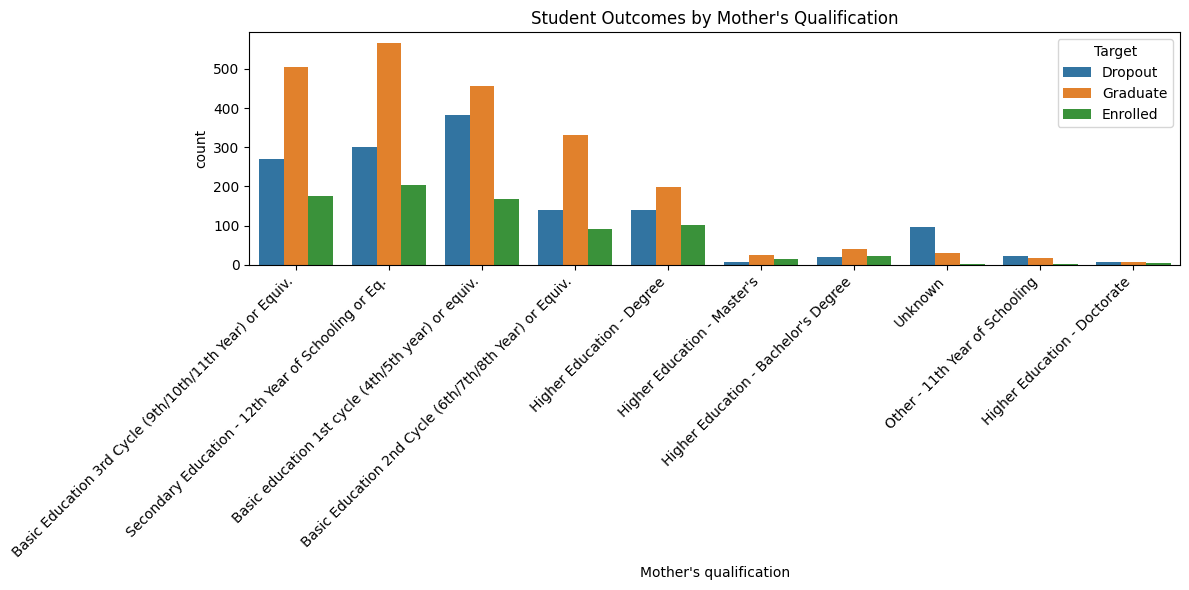

In [54]:
# Create a count plot to visualize the distribution
# of student outcomes across mother's education levels

plt.figure(figsize=(12,6))

sns.countplot(
    x="Mother's qualification",
    hue="Target",
    data=mother_df
)

plt.xticks(rotation=45, ha="right")
plt.title("Student Outcomes by Mother's Qualification")
plt.tight_layout()
plt.show()

The results suggest that parental education level may be associated with student success. Students whose mothers completed higher levels of education generally show higher graduation rates and lower dropout rates than students whose mothers have lower levels of formal education. For example, students whose mothers completed secondary education or higher education tend to have graduation rates above 45–50%, while several lower education categories show noticeably higher dropout percentages. Additionally, the "Unknown" category has the highest dropout rate (73.85%) and one of the lowest graduation rates (23.85%), suggesting that missing parental education information may be associated with increased academic risk. Overall, the data indicates that higher maternal educational attainment is generally linked with more favorable student outcomes.

In [58]:
# Display the frequency of each father's education level
# to identify the most common qualification categories

df_raw["Father's qualification"].value_counts()

Father's qualification
Basic education 1st cycle (4th/5th year) or equiv.          1209
Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.     968
Secondary Education - 12th Year of Schooling or Eq.          904
Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.       702
Higher Education - Degree                                    282
Unknown                                                      112
Higher Education - Bachelor's Degree                          68
Higher Education - Master's                                   39
Other - 11th Year of Schooling                                38
Technological specialization course                           20
Higher Education - Doctorate                                  18
7th Year (Old)                                                10
Can read without having a 4th year of schooling                8
12th Year of Schooling - Not Completed                         5
Higher education - degree (1st cycle)                          5
10

In [61]:
# Select the 10 most common father's qualification categories
# to simplify the analysis and improve readability

top_fathers = df_raw["Father's qualification"].value_counts().head(10).index

father_df = df_raw[
    df_raw["Father's qualification"].isin(top_fathers)
]

In [63]:
# Calculate the percentage of students who dropped out,
# remained enrolled, or graduated within each father's
# education level category

(
    pd.crosstab(
        father_df["Father's qualification"],
        father_df["Target"],
        normalize="index"
    ) * 100
).round(2)

Target,Dropout,Enrolled,Graduate
Father's qualification,,,
Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.,23.79,18.09,58.12
Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.,27.27,18.90,53.82
Basic education 1st cycle (4th/5th year) or equiv.,35.73,16.46,47.81
Higher Education - Bachelor's Degree,32.35,36.76,30.88
Higher Education - Degree,31.91,21.99,46.10
Higher Education - Master's,35.90,17.95,46.15
Other - 11th Year of Schooling,36.84,10.53,52.63
Secondary Education - 12th Year of Schooling or Eq.,31.08,19.03,49.89
Technological specialization course,40.00,35.00,25.00


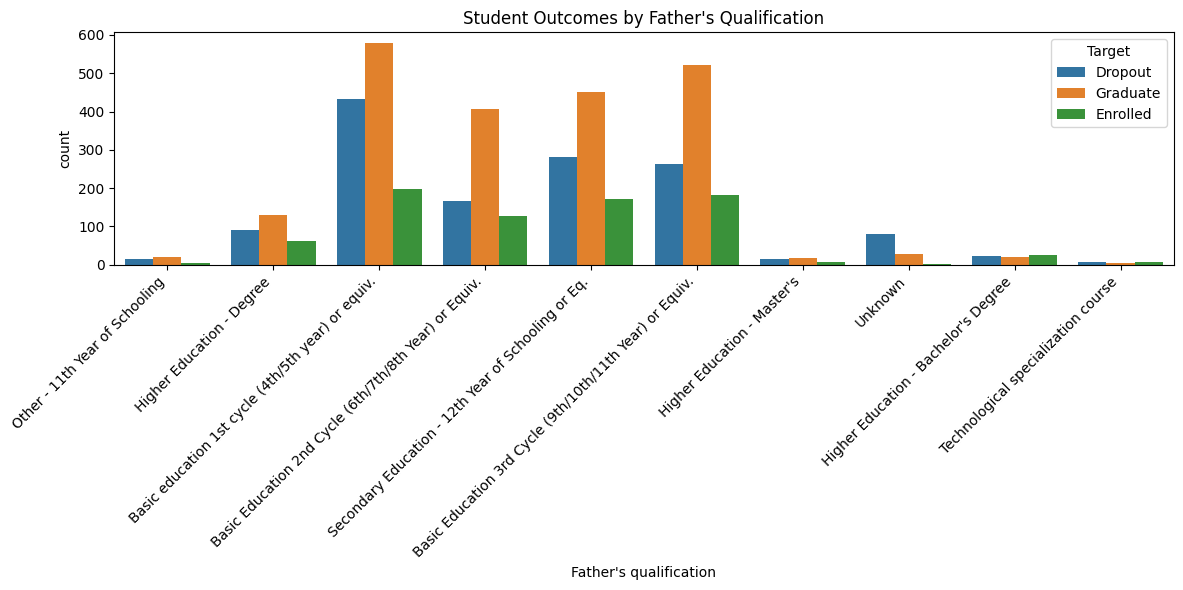

In [64]:
# Create a count plot to visualize the distribution
# of student outcomes across father's education levels

plt.figure(figsize=(12,6))

sns.countplot(
    x="Father's qualification",
    hue="Target",
    data=father_df
)

plt.xticks(rotation=45, ha="right")
plt.title("Student Outcomes by Father's Qualification")
plt.tight_layout()
plt.show()

The results suggest that a father's education level may also be associated with student outcomes. Students whose fathers attained higher levels of education generally show lower dropout rates and higher graduation rates compared to students whose fathers completed fewer years of formal schooling. For example, students whose fathers completed secondary education or higher education typically have graduation rates between approximately 46% and 54%, while many lower education categories exhibit higher dropout percentages. Additionally, the "Unknown" category shows the highest dropout rate (72.32%) and one of the lowest graduation rates (25.00%), indicating that missing parental education information may be associated with increased academic risk. Overall, the findings suggest that higher paternal educational attainment is generally linked with more favorable student outcomes.

Guiding Question #4: 